In [1]:
!pip install thop openpyxl scikit-learn -q

Import libraries

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import time

from sklearn.metrics import precision_score, recall_score
from thop import profile

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


Importing the dataset

In [16]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Load Pretrained ResNet34

In [17]:
model = models.resnet34(weights="DEFAULT")

# Replace final layer for CIFAR-10
model.fc = nn.Linear(model.fc.in_features, 10)

model = model.to(device)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Parameters

In [18]:
num_params = sum(p.numel() for p in model.parameters())
print("Number of parameters:", num_params)

dummy_input = torch.randn(1, 3, 224, 224).to(device)

flops, params = profile(model, inputs=(dummy_input,))
print("FLOPs:", flops)

Number of parameters: 21289802
[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.MaxPool2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register count_adap_avgpool() for <class 'torch.nn.modules.pooling.AdaptiveAvgPool2d'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
FLOPs: 3678232576.0


Hyperparameters

In [19]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.001,
    momentum=0.9,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.1
)

num_epochs = 5

History Dictionary

In [20]:
history = {
    "Epoch": [],
    "Train Loss": [],
    "Train Accuracy Top1": [],
    "Train Accuracy Top5": [],
    "Test Loss": [],
    "Test Accuracy Top1": [],
    "Test Accuracy Top5": []
}

Training loop

In [21]:
for epoch in range(num_epochs):
    model.train()

    train_loss = 0
    correct_top1 = 0
    correct_top5 = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, predicted = outputs.max(1)
        correct_top1 += predicted.eq(labels).sum().item()

        _, top5_pred = outputs.topk(5, dim=1)
        correct_top5 += top5_pred.eq(
            labels.view(-1, 1)
        ).sum().item()

        total += labels.size(0)

    train_acc_top1 = 100 * correct_top1 / total
    train_acc_top5 = 100 * correct_top5 / total
    avg_train_loss = train_loss / len(train_loader)

    # Testing
    model.eval()

    test_loss = 0
    test_top1 = 0
    test_top5 = 0
    total_test = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, predicted = outputs.max(1)
            test_top1 += predicted.eq(labels).sum().item()

            _, top5_pred = outputs.topk(5, dim=1)
            test_top5 += top5_pred.eq(
                labels.view(-1, 1)
            ).sum().item()

            total_test += labels.size(0)

    test_acc_top1 = 100 * test_top1 / total_test
    test_acc_top5 = 100 * test_top5 / total_test
    avg_test_loss = test_loss / len(test_loader)

    scheduler.step()

    history["Epoch"].append(epoch + 1)
    history["Train Loss"].append(avg_train_loss)
    history["Train Accuracy Top1"].append(train_acc_top1)
    history["Train Accuracy Top5"].append(train_acc_top5)
    history["Test Loss"].append(avg_test_loss)
    history["Test Accuracy Top1"].append(test_acc_top1)
    history["Test Accuracy Top5"].append(test_acc_top5)

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Fine tune Loss: {avg_train_loss:.4f} | "
          f"Fine tune Accuracy Top1: {train_acc_top1:.2f}% | "
          f"Fine tune Accuracy Top5: {train_acc_top5:.2f}% | "
          f"Test Loss: {avg_test_loss:.4f} | "
          f"Test Accuracy Top1: {test_acc_top1:.2f}% | "
          f"TestAccuracy Top5: {test_acc_top5:.2f}%")

Epoch [1/5] | Fine tune Loss: 0.3798 | Fine tune Accuracy Top1: 87.95% | Fine tune Accuracy Top5: 98.71% | Test Loss: 0.1705 | Test Accuracy Top1: 94.12% | TestAccuracy Top5: 99.93%
Epoch [2/5] | Fine tune Loss: 0.1284 | Fine tune Accuracy Top1: 95.84% | Fine tune Accuracy Top5: 99.94% | Test Loss: 0.1305 | Test Accuracy Top1: 95.39% | TestAccuracy Top5: 99.96%
Epoch [3/5] | Fine tune Loss: 0.0833 | Fine tune Accuracy Top1: 97.26% | Fine tune Accuracy Top5: 99.99% | Test Loss: 0.1275 | Test Accuracy Top1: 95.66% | TestAccuracy Top5: 99.97%
Epoch [4/5] | Fine tune Loss: 0.0569 | Fine tune Accuracy Top1: 98.20% | Fine tune Accuracy Top5: 99.99% | Test Loss: 0.1171 | Test Accuracy Top1: 96.10% | TestAccuracy Top5: 99.95%
Epoch [5/5] | Fine tune Loss: 0.0395 | Fine tune Accuracy Top1: 98.79% | Fine tune Accuracy Top5: 100.00% | Test Loss: 0.1209 | Test Accuracy Top1: 96.07% | TestAccuracy Top5: 99.95%


Results

In [22]:
def evaluate(loader):
    model.eval()
    total_loss = 0
    correct_top1 = 0
    correct_top5 = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, pred = outputs.max(1)
            correct_top1 += pred.eq(labels).sum().item()

            _, top5_pred = outputs.topk(5, dim=1)
            correct_top5 += top5_pred.eq(
                labels.view(-1,1)
            ).sum().item()

            total += labels.size(0)

    acc_top1 = 100 * correct_top1 / total
    acc_top5 = 100 * correct_top5 / total
    avg_loss = total_loss / len(loader)

    return avg_loss, acc_top1, acc_top5

In [23]:
final_test_loss, final_test_top1, final_test_top5 = evaluate(test_loader)

test_error = 100 - final_test_top1

print("Final Test Accuracy Top1:", final_test_top1)
print("Final Test Accuracy Top5:", final_test_top5)
print("Final Test Loss:", final_test_loss)
print("Test Error %:", test_error)

Final Test Accuracy Top1: 96.07
Final Test Accuracy Top5: 99.95
Final Test Loss: 0.12094924543171552
Test Error %: 3.930000000000007


In [24]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, preds = outputs.max(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.9608358930293159
Recall: 0.9606999999999999


Inference time

In [25]:
start = time.time()

with torch.no_grad():
    _ = model(dummy_input)

end = time.time()

print("Inference time:", end - start)

Inference time: 0.008454084396362305


Plots

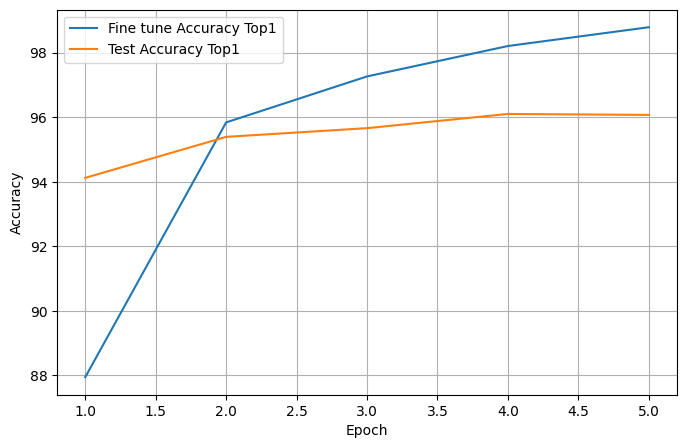

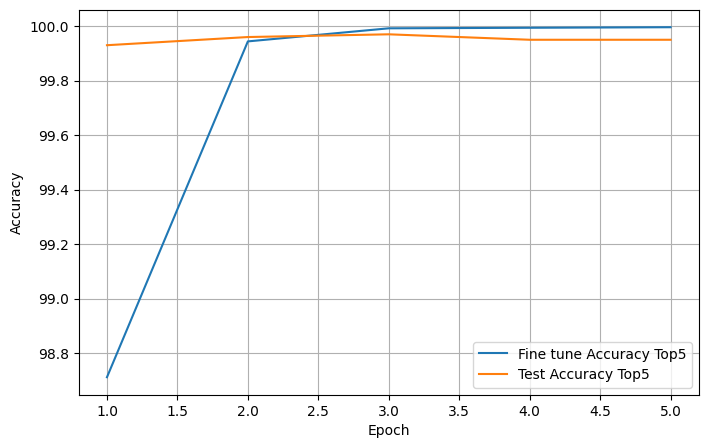

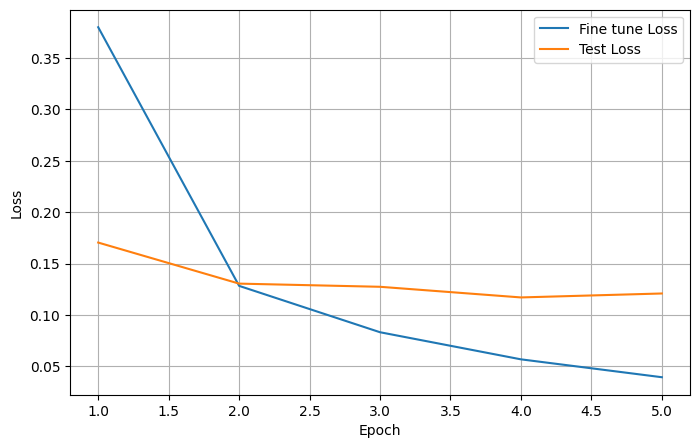

In [26]:
epochs = history["Epoch"]

plt.figure(figsize=(8,5))
plt.plot(epochs, history["Train Accuracy Top1"], label="Fine tune Accuracy Top1")
plt.plot(epochs, history["Test Accuracy Top1"], label="Test Accuracy Top1")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(epochs, history["Train Accuracy Top5"], label="Fine tune Accuracy Top5")
plt.plot(epochs, history["Test Accuracy Top5"], label="Test Accuracy Top5")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(epochs, history["Train Loss"], label="Fine tune Loss")
plt.plot(epochs, history["Test Loss"], label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

Excel file

In [27]:
df = pd.DataFrame(history)

df["Final Precision"] = precision
df["Final Recall"] = recall
df["Parameters"] = num_params
df["FLOPs"] = flops

df.to_excel("resnet34_cifar10_baseline.xlsx", index=False)

print("Excel file saved successfully")

Excel file saved successfully
